In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor

In [2]:
day = pd.read_csv("day.csv")

# Drop required columns
day.drop(
    columns=["instant", "dteday", "yr", "casual", "registered"],
    inplace=True
)

# Remove duplicates
day.drop_duplicates(inplace=True)

# Handle missing values
day.fillna(day.median(numeric_only=True), inplace=True)


In [3]:
# Sort properly (important for lag features)
day = day.sort_values(by=["mnth", "weekday"])

# Lag features
day["cnt_lag_1"] = day["cnt"].shift(1)     # previous day
day["cnt_lag_7"] = day["cnt"].shift(7)     # previous week

# Rolling features
day["cnt_roll_3"] = day["cnt"].rolling(3).mean()
day["cnt_roll_7"] = day["cnt"].rolling(7).mean()

# Drop rows created by lag/rolling
day.dropna(inplace=True)


In [4]:
X = day.drop("cnt", axis=1)
y = day["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [6]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)


R2 Score: 0.8175521794988934
RMSE: 849.3896236844344


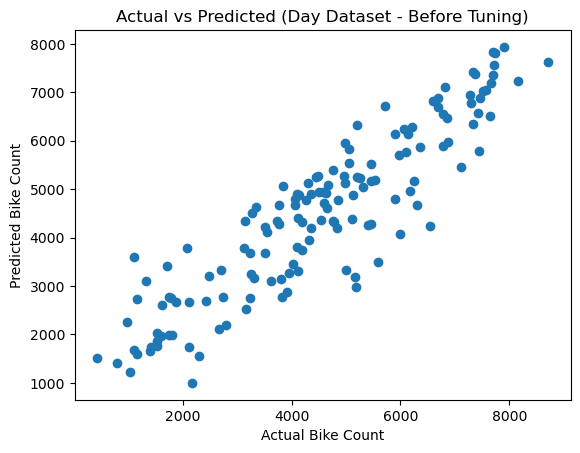

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count")
plt.title("Actual vs Predicted (Day Dataset - Before Tuning)")
plt.show()

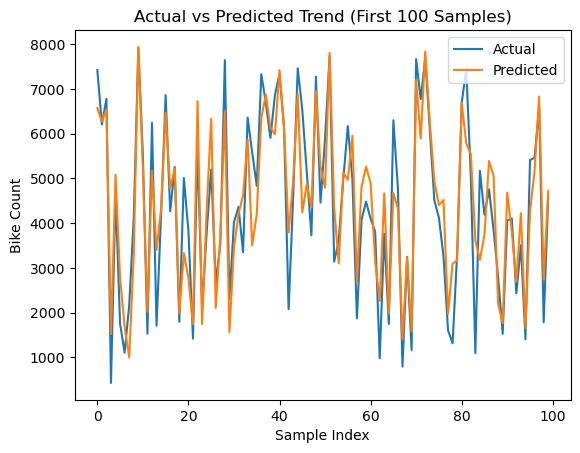

In [8]:
plt.figure()
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("Bike Count")
plt.title("Actual vs Predicted Trend (First 100 Samples)")
plt.legend()
plt.show()

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor

In [10]:
hour = pd.read_csv("hour.csv")

# Drop required columns
hour.drop(
    columns=["instant", "dteday", "yr", "casual", "registered"],
    inplace=True
)

# Remove duplicates
hour.drop_duplicates(inplace=True)

# Handle missing values
hour.fillna(hour.median(numeric_only=True), inplace=True)

In [11]:
# Sort by time-related columns
hour = hour.sort_values(by=["mnth", "hr"])

# Lag features
hour["cnt_lag_1"] = hour["cnt"].shift(1)
hour["cnt_lag_24"] = hour["cnt"].shift(24)

# Rolling features
hour["cnt_roll_3"] = hour["cnt"].rolling(window=3).mean()
hour["cnt_roll_24"] = hour["cnt"].rolling(window=24).mean()

# Remove NaN created by lag/rolling
hour.dropna(inplace=True)

In [12]:
X = hour.drop("cnt", axis=1)
y = hour["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [14]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.9514435921083284
RMSE: 41.08755923537745


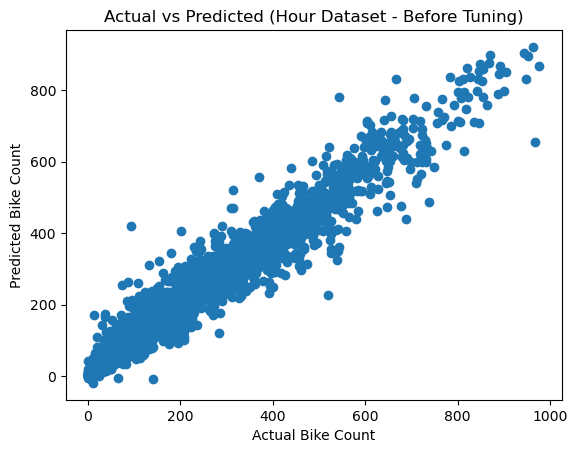

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count")
plt.title("Actual vs Predicted (Hour Dataset - Before Tuning)")
plt.show()

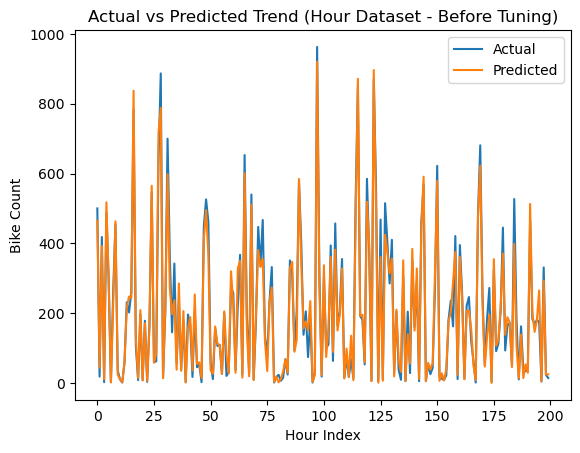

In [16]:
plt.figure()
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.xlabel("Hour Index")
plt.ylabel("Bike Count")
plt.title("Actual vs Predicted Trend (Hour Dataset - Before Tuning)")
plt.legend()
plt.show()